# GAIA Paraphrase Trace Predictor Study

This notebook studies **execution prediction from query embeddings** on the augmented GAIA benchmark.

Setup:
- Load logged traces from `results/claude_native/<RUN_NAME>/*/normalized_trace.json`
- Compute accuracy summary
- **Filter to successful traces only**
- Compute prompt embeddings
- Run repeated random **80/20 train/test splits**
- Train simple predictors from embeddings to:
  1. predict `total_steps`
  2. predict the binary tool-set vector
  3. predict the tool-count vector
  4. predict the sequence-transition vector

Evaluation:
- Step count: **MAE**, **RMSE**
- Tool set: **subset accuracy**, **micro/macro F1**, **row-wise cosine similarity**
- Tool count: **row-wise cosine similarity**, **MAE**
- Tool sequence-transition: **row-wise cosine similarity**, **MAE**

Notes:
- The split is **per-prompt random 80/20**, repeated across multiple seeds.
- Because the augmented benchmark contains paraphrases, this is a relatively optimistic setting.

In [1]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option("display.max_colwidth", 120)

## 1. Load traces

In [2]:
# ============================================================
# Project / run configuration
# ============================================================
DEFAULT_PROJECT_ROOT = Path("/home/tungichen_umass_edu/ekb-claude-pilot")
PROJECT_ROOT = DEFAULT_PROJECT_ROOT if DEFAULT_PROJECT_ROOT.exists() else Path.cwd().resolve()

RESULTS_ROOT = PROJECT_ROOT / "results" / "claude_native"

# Change this to the run folder you want to analyze
RUN_NAME = "gaia_level1_expanded_claude_native_maxturn12"

RUN_ROOT = RESULTS_ROOT / RUN_NAME
OUTPUT_DIR = PROJECT_ROOT / "results" / "analysis" / f"{RUN_NAME}_predictor"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_ROOT:", RUN_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def iter_normalized_trace_paths(run_root: Path):
    if not run_root.exists():
        raise FileNotFoundError(f"Trace root does not exist: {run_root}")
    for path in sorted(run_root.glob("*/normalized_trace.json")):
        yield path

def canonical_tool_name(tool):
    if tool is None:
        return "unknown"
    tool = str(tool).strip()
    mapping = {
        "WebSearch": "WebSearch",
        "WebFetch": "WebFetch",
        "Bash": "Bash",
        "Read": "Read",
        "Write": "Write",
        "Edit": "Edit",
        "Grep": "Grep",
        "Glob": "Glob",
        "ToolSearch": "ToolSearch",
        "StructuredOutput": "StructuredOutput",
    }
    return mapping.get(tool, tool)

def extract_steps(trace: dict):
    steps = trace.get("steps", [])
    if not isinstance(steps, list):
        return []

    out = []
    for s in steps:
        if not isinstance(s, dict):
            continue
        out.append({
            "step": s.get("step"),
            "tool": canonical_tool_name(s.get("tool")),
            "status": s.get("status"),
            "latency_ms": s.get("latency_ms"),
        })
    return out

def safe_num(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def build_trace_record(path: Path):
    trace = load_json(path)
    steps = extract_steps(trace)

    tools_all = [s["tool"] for s in steps]
    tool_counts = Counter(tools_all)

    record = {
        "query_id": trace.get("query_id"),
        "query_text": trace.get("query_text", ""),
        "benchmark": trace.get("benchmark"),
        "split": trace.get("split"),
        "level": trace.get("level"),
        "agent": trace.get("agent"),
        "model_requested": trace.get("model_requested"),
        "effort": trace.get("effort"),

        # scalar execution attributes
        "total_steps": int(trace.get("total_steps", len(steps) or 0)),
        "total_tool_calls": int(trace.get("total_tool_calls", len(steps) or 0)),
        "total_latency_ms": safe_num(trace.get("total_latency_ms")),
        "total_tokens": safe_num(trace.get("total_tokens")),

        # sequence / set views
        "tool_sequence_all": tools_all,
        "tools_used": sorted(set(tools_all)),

        # answer/eval fields
        "success": trace.get("success"),
        "final_answer_pred": trace.get("final_answer_pred"),
        "ground_truth_answer": trace.get("ground_truth_answer"),
        "exact_match": trace.get("exact_match"),
        "result_text": trace.get("result_text"),

        # bookkeeping
        "normalized_trace_path": str(path),
        "task_dir": str(path.parent),
        "run_name": path.parent.parent.name,
        "task_folder_name": path.parent.name,

        # keep raw tool counts temporarily for dense expansion later
        "_tool_counts": dict(tool_counts),
    }
    return record

# ============================================================
# Load traces
# ============================================================
trace_paths = list(iter_normalized_trace_paths(RUN_ROOT))
print(f"Found {len(trace_paths)} normalized_trace.json files under {RUN_ROOT}")

trace_records = [build_trace_record(p) for p in trace_paths]
df_all = pd.DataFrame(trace_records)

print(f"Loaded {len(df_all)} normalized traces.")

# ------------------------------------------------------------
# Expand dense tool_count__* columns
# ------------------------------------------------------------
all_tools = sorted({
    tool
    for record in trace_records
    for tool in record["_tool_counts"].keys()
})

for tool in all_tools:
    col = f"tool_count__{tool}"
    df_all[col] = df_all["_tool_counts"].apply(lambda d: int(d.get(tool, 0)))

df_all = df_all.drop(columns=["_tool_counts"])

for c in ["total_steps", "total_tool_calls", "total_latency_ms", "total_tokens"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

df_all["total_steps"] = df_all["total_steps"].fillna(0).astype(int)
df_all["total_tool_calls"] = df_all["total_tool_calls"].fillna(0).astype(int)
df_all["total_latency_ms"] = df_all["total_latency_ms"].fillna(0.0)
df_all["total_tokens"] = df_all["total_tokens"].fillna(0.0)

tool_count_cols = sorted([c for c in df_all.columns if c.startswith("tool_count__")])

display_cols = [
    "query_id",
    "query_text",
    "total_steps",
    "total_tool_calls",
    "total_latency_ms",
    "total_tokens",
    "tool_sequence_all",
    "tools_used",
    "success",
    "exact_match",
] + tool_count_cols

display(df_all[display_cols].head(5))
print("Observed tools:", all_tools)
print("Tool-count columns:", tool_count_cols)

PROJECT_ROOT: /home/tungichen_umass_edu/ekb-claude-pilot
RUN_ROOT: /home/tungichen_umass_edu/ekb-claude-pilot/results/claude_native/gaia_level1_expanded_claude_native_maxturn12
OUTPUT_DIR: /home/tungichen_umass_edu/ekb-claude-pilot/results/analysis/gaia_level1_expanded_claude_native_maxturn12_predictor
Found 202 normalized_trace.json files under /home/tungichen_umass_edu/ekb-claude-pilot/results/claude_native/gaia_level1_expanded_claude_native_maxturn12
Loaded 202 normalized traces.


,query_id,query_text,total_steps,total_tool_calls,total_latency_ms,total_tokens,tool_sequence_all,tools_used,success,exact_match,tool_count__Bash,tool_count__Glob,tool_count__Read,tool_count__StructuredOutput,tool_count__ToolSearch,tool_count__WebFetch,tool_count__WebSearch
0,0383a3ee-47a7-41a4-b493-519bdefe0488,"On the BBC Earth YouTube video of the Top 5 Silliest Animal Moments, what species of bird is featured?",9,9,83683.0,204013.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, WebFetch, WebFetch, WebSearch, WebFetch, StructuredOutput]","[StructuredOutput, ToolSearch, WebFetch, WebSearch]",True,False,0,0,0,1,2,4,2
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,"In the BBC Earth YouTube video titled Top 5 Silliest Animal Moments, which bird species appears?",8,8,49461.0,179148.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, WebFetch, WebFetch, WebSearch, StructuredOutput]","[StructuredOutput, ToolSearch, WebFetch, WebSearch]",True,True,0,0,0,1,2,3,2
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,What bird species is shown in the BBC Earth YouTube video called Top 5 Silliest Animal Moments?,11,11,144579.0,249898.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, WebSearch, WebFetch, WebFetch, WebSearch, StructuredOutput, WebFetch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSearch]",True,True,0,0,0,2,2,4,3
3,0383a3ee-47a7-41a4-b493-519bdefe0488__para3,Which species of bird can be seen in BBC Earth's YouTube video Top 5 Silliest Animal Moments?,10,10,71740.0,225716.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, WebFetch, WebSearch, WebFetch, WebFetch, WebSearch, StructuredOutput]","[StructuredOutput, ToolSearch, WebFetch, WebSearch]",True,True,0,0,0,1,2,4,3
4,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,How many more blocks (also denoted as layers) in BERT base encoder than the encoder from the architecture proposed i...,1,1,9087.0,35542.0,[StructuredOutput],[StructuredOutput],True,True,0,0,0,1,0,0,0


Observed tools: ['Bash', 'Glob', 'Read', 'StructuredOutput', 'ToolSearch', 'WebFetch', 'WebSearch']
Tool-count columns: ['tool_count__Bash', 'tool_count__Glob', 'tool_count__Read', 'tool_count__StructuredOutput', 'tool_count__ToolSearch', 'tool_count__WebFetch', 'tool_count__WebSearch']


## 2. Accuracy summary + filter to successful traces

In [3]:
# ============================================================
# Accuracy summary + SUCCESS-ONLY filtering for predictor study
# ============================================================
n_total = len(df_all)
n_success = int(df_all["success"].fillna(False).sum())
n_fail = n_total - n_success

# exact_match among all traces with non-null labels
acc_all = pd.to_numeric(df_all["exact_match"], errors="coerce")
overall_accuracy = float(acc_all.fillna(False).mean()) if n_total > 0 else np.nan

# exact_match among successful traces only
acc_success = pd.to_numeric(
    df_all.loc[df_all["success"].fillna(False), "exact_match"],
    errors="coerce"
)
success_accuracy = float(acc_success.fillna(False).mean()) if n_success > 0 else np.nan

print(f"Total traces loaded         : {n_total}")
print(f"Successful traces           : {n_success}")
print(f"Failed traces               : {n_fail}")
print(f"Overall exact-match accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Success-only accuracy       : {success_accuracy:.4f} ({success_accuracy*100:.2f}%)")

# ------------------------------------------------------------
# Only keep successful traces for the analyses below
# ------------------------------------------------------------
df = df_all.loc[df_all["success"].fillna(False)].copy().reset_index(drop=True)

print(f"Filtered to {len(df)} successful traces for predictor analysis.")
display(df[[
    "query_id",
    "query_text",
    "success",
    "exact_match",
    "total_steps",
    "total_latency_ms",
    "total_tokens",
]].head(5))

Total traces loaded         : 202
Successful traces           : 163
Failed traces               : 39
Overall exact-match accuracy: 0.6980 (69.80%)
Success-only accuracy       : 0.8650 (86.50%)
Filtered to 163 successful traces for predictor analysis.


,query_id,query_text,success,exact_match,total_steps,total_latency_ms,total_tokens
0,0383a3ee-47a7-41a4-b493-519bdefe0488,"On the BBC Earth YouTube video of the Top 5 Silliest Animal Moments, what species of bird is featured?",True,False,9,83683.0,204013.0
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,"In the BBC Earth YouTube video titled Top 5 Silliest Animal Moments, which bird species appears?",True,True,8,49461.0,179148.0
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,What bird species is shown in the BBC Earth YouTube video called Top 5 Silliest Animal Moments?,True,True,11,144579.0,249898.0
3,0383a3ee-47a7-41a4-b493-519bdefe0488__para3,Which species of bird can be seen in BBC Earth's YouTube video Top 5 Silliest Animal Moments?,True,True,10,71740.0,225716.0
4,11af4e1a-5f45-467d-9aeb-46f4bb0bf034,How many more blocks (also denoted as layers) in BERT base encoder than the encoder from the architecture proposed i...,True,True,1,9087.0,35542.0


## 3. Prompt embeddings

In [4]:
# ============================================================
# Prompt embedding backend with fallback
# ============================================================
EMBEDDING_BACKEND = None

def make_embeddings(texts):
    global EMBEDDING_BACKEND
    texts = [str(t) for t in texts]

    try:
        from sentence_transformers import SentenceTransformer
        model_name = "sentence-transformers/all-MiniLM-L6-v2"
        model = SentenceTransformer(model_name)
        X = model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
        EMBEDDING_BACKEND = model_name
        return np.asarray(X, dtype=np.float32)
    except Exception as e:
        print("SentenceTransformer unavailable; falling back to TF-IDF + SVD")
        print("Reason:", repr(e))
        vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X_tfidf = vectorizer.fit_transform(texts)
        n_components = min(128, max(2, X_tfidf.shape[1] - 1))
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        X = svd.fit_transform(X_tfidf)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        X = X / norms
        EMBEDDING_BACKEND = "tfidf+svd"
        return np.asarray(X, dtype=np.float32)

X_embed = make_embeddings(df["query_text"].tolist())
print("Embedding backend:", EMBEDDING_BACKEND)
print("Embedding shape:", X_embed.shape)

/work/pi_rsitaram_umass_edu/tungi/conda/envs/ekb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 6/6 [00:00<00:00, 23.54it/s]

Embedding backend: sentence-transformers/all-MiniLM-L6-v2
Embedding shape: (163, 384)


## 4. Build execution representations

In [5]:
# ============================================================
# Tool-set / tool-count / sequence-transition representations
# ============================================================

from sklearn.preprocessing import MultiLabelBinarizer

def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

# ------------------------------------------------------------
# Tool-set binary matrix
# ------------------------------------------------------------
tool_sets = df["tools_used"].apply(as_list).tolist()

mlb_tools = MultiLabelBinarizer()
X_toolset_binary = mlb_tools.fit_transform(tool_sets).astype(np.float32)
toolset_feature_names = list(mlb_tools.classes_)

print("X_toolset_binary shape:", X_toolset_binary.shape)
print("Tool-set features:", toolset_feature_names)

# ------------------------------------------------------------
# Tool-count matrix
# ------------------------------------------------------------
tool_count_cols_success = sorted([c for c in df.columns if c.startswith("tool_count__")])
X_toolcount = df[tool_count_cols_success].to_numpy(dtype=np.float32)

print("X_toolcount shape:", X_toolcount.shape)

# ------------------------------------------------------------
# Sequence-transition matrix
# ------------------------------------------------------------
from collections import Counter

tool_sequences = df["tool_sequence_all"].apply(as_list).tolist()

observed_transitions = sorted({
    (seq[k], seq[k + 1])
    for seq in tool_sequences
    for k in range(len(seq) - 1)
})

transition_to_idx = {tr: idx for idx, tr in enumerate(observed_transitions)}
transition_feature_names = [f"{a}->{b}" for (a, b) in observed_transitions]

X_tool_transition = np.zeros((len(tool_sequences), len(observed_transitions)), dtype=np.float32)

for i, seq in enumerate(tool_sequences):
    counts = Counter((seq[k], seq[k + 1]) for k in range(len(seq) - 1))
    for tr, cnt in counts.items():
        X_tool_transition[i, transition_to_idx[tr]] = float(cnt)

print("X_tool_transition shape:", X_tool_transition.shape)
print("Number of observed transitions:", len(observed_transitions))

# Scalar target
y_steps = df["total_steps"].to_numpy(dtype=np.float32)
print("y_steps shape:", y_steps.shape)

X_toolset_binary shape: (163, 7)
Tool-set features: ['Bash', 'Glob', 'Read', 'StructuredOutput', 'ToolSearch', 'WebFetch', 'WebSearch']
X_toolcount shape: (163, 7)
X_tool_transition shape: (163, 36)
Number of observed transitions: 36
y_steps shape: (163,)


## 5. Prediction setup

In [6]:
# ============================================================
# Shared helpers and configuration
# ============================================================

TEST_SIZE = 0.20
N_REPEATS = 20
RANDOM_SEEDS = list(range(100, 100 + N_REPEATS))
KNN_K = 5

print(f"N successful samples: {len(df)}")
print(f"Test size: {TEST_SIZE}")
print(f"N repeats: {N_REPEATS}")
print(f"KNN neighbors: {KNN_K}")

def rowwise_cosine(A, B, eps=1e-12):
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)

    num = np.sum(A * B, axis=1)
    den = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    den = np.maximum(den, eps)
    return num / den

def safe_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return float(np.sqrt(mse))

def summarize_runs(df_runs, metric_cols):
    rows = []
    for col in metric_cols:
        rows.append({
            "metric": col,
            "mean": float(df_runs[col].mean()),
            "std": float(df_runs[col].std(ddof=1)),
        })
    return pd.DataFrame(rows)

def make_knn_regressor():
    return KNeighborsRegressor(
        n_neighbors=KNN_K,
        weights="distance",
        metric="cosine",
        algorithm="brute",
    )

def make_knn_classifier():
    return KNeighborsClassifier(
        n_neighbors=KNN_K,
        weights="distance",
        metric="cosine",
        algorithm="brute",
    )

N successful samples: 163
Test size: 0.2
N repeats: 20
KNN neighbors: 5


## 6. Predict step count from embeddings

In [7]:
# ============================================================
# Predict total_steps from query embeddings
# Eval: MAE, RMSE
# ============================================================

X = np.asarray(X_embed, dtype=np.float32)
y = y_steps

step_runs = []

for seed in RANDOM_SEEDS:
    idx = np.arange(len(X))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=seed,
        shuffle=True,
    )

    X_train, X_test = X[idx_train], X[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]

    model = make_knn_regressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    step_runs.append({
        "seed": seed,
        "mae": float(mean_absolute_error(y_test, y_pred)),
        "rmse": safe_rmse(y_test, y_pred),
    })

df_step_runs = pd.DataFrame(step_runs)
df_step_summary = summarize_runs(df_step_runs, ["mae", "rmse"])

display(df_step_runs)
display(df_step_summary)

df_step_runs.to_csv(OUTPUT_DIR / "step_prediction_runs.csv", index=False)
df_step_summary.to_csv(OUTPUT_DIR / "step_prediction_summary.csv", index=False)

,seed,mae,rmse
0,100,2.114365,3.169668
1,101,3.122692,5.071664
2,102,3.771013,5.280006
3,103,3.910154,5.937526
4,104,2.610579,3.912378
5,105,3.765904,5.192371
6,106,1.328188,2.016605
7,107,2.766567,4.925146
8,108,2.907113,4.477899
9,109,1.889185,3.189215


,metric,mean,std
0,mae,2.724210,0.768664
1,rmse,4.170456,1.155662


## 7. Predict tool set from embeddings

In [8]:
# ============================================================
# Predict tool-set binary vector from query embeddings
# Eval:
#   - subset accuracy
#   - micro F1
#   - macro F1
#   - mean row-wise cosine similarity
# ============================================================

X = np.asarray(X_embed, dtype=np.float32)
Y_toolset = np.asarray(X_toolset_binary, dtype=np.int32)

toolset_runs = []

for seed in RANDOM_SEEDS:
    idx = np.arange(len(X))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=seed,
        shuffle=True,
    )

    X_train, X_test = X[idx_train], X[idx_test]
    Y_train, Y_test = Y_toolset[idx_train], Y_toolset[idx_test]

    clf = make_knn_classifier()
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test).astype(np.int32)

    row_cos = rowwise_cosine(Y_test, Y_pred)

    toolset_runs.append({
        "seed": seed,
        "subset_accuracy": float(accuracy_score(Y_test, Y_pred)),
        "micro_f1": float(f1_score(Y_test, Y_pred, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(Y_test, Y_pred, average="macro", zero_division=0)),
        "mean_toolset_binary_cosine": float(np.mean(row_cos)),
    })

df_toolset_runs = pd.DataFrame(toolset_runs)
df_toolset_summary = summarize_runs(
    df_toolset_runs,
    ["subset_accuracy", "micro_f1", "macro_f1", "mean_toolset_binary_cosine"],
)

display(df_toolset_runs)
display(df_toolset_summary)

df_toolset_runs.to_csv(OUTPUT_DIR / "toolset_prediction_runs.csv", index=False)
df_toolset_summary.to_csv(OUTPUT_DIR / "toolset_prediction_summary.csv", index=False)

,seed,subset_accuracy,micro_f1,macro_f1,mean_toolset_binary_cosine
0,100,0.757576,0.919431,0.789464,0.926818
1,101,0.727273,0.918919,0.700165,0.926574
2,102,0.787879,0.929577,0.654978,0.929683
3,103,0.666667,0.881720,0.691964,0.910078
4,104,0.696970,0.907216,0.795389,0.918255
5,105,0.606061,0.895238,0.745938,0.904053
6,106,0.787879,0.928571,0.768773,0.947096
7,107,0.757576,0.904762,0.813698,0.922166
8,108,0.818182,0.956989,0.777772,0.964828
9,109,0.757576,0.917526,0.860217,0.933878


,metric,mean,std
0,subset_accuracy,0.742424,0.057748
1,micro_f1,0.915777,0.016082
2,macro_f1,0.776759,0.066541
3,mean_toolset_binary_cosine,0.927316,0.015641


## 8. Predict tool count from embeddings

In [9]:
# ============================================================
# Predict tool-count vector from query embeddings
# Eval:
#   - mean row-wise cosine similarity
#   - MAE
# ============================================================

X = np.asarray(X_embed, dtype=np.float32)
Y_toolcount = np.asarray(X_toolcount, dtype=np.float32)

toolcount_runs = []

for seed in RANDOM_SEEDS:
    idx = np.arange(len(X))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=seed,
        shuffle=True,
    )

    X_train, X_test = X[idx_train], X[idx_test]
    Y_train, Y_test = Y_toolcount[idx_train], Y_toolcount[idx_test]

    reg = make_knn_regressor()
    reg.fit(X_train, Y_train)
    Y_pred = reg.predict(X_test)
    Y_pred = np.clip(Y_pred, 0.0, None)

    row_cos = rowwise_cosine(Y_test, Y_pred)

    toolcount_runs.append({
        "seed": seed,
        "mean_toolcount_cosine": float(np.mean(row_cos)),
        "mae": float(mean_absolute_error(Y_test, Y_pred)),
    })

df_toolcount_runs = pd.DataFrame(toolcount_runs)
df_toolcount_summary = summarize_runs(
    df_toolcount_runs,
    ["mean_toolcount_cosine", "mae"],
)

display(df_toolcount_runs)
display(df_toolcount_summary)

df_toolcount_runs.to_csv(OUTPUT_DIR / "toolcount_prediction_runs.csv", index=False)
df_toolcount_summary.to_csv(OUTPUT_DIR / "toolcount_prediction_summary.csv", index=False)

,seed,mean_toolcount_cosine,mae
0,100,0.905785,0.455660
1,101,0.895065,0.599182
2,102,0.881071,0.646290
3,103,0.873050,0.761030
4,104,0.868327,0.474261
5,105,0.841558,0.701584
6,106,0.926048,0.373647
7,107,0.864986,0.627920
8,108,0.872309,0.499787
9,109,0.869365,0.369840


,metric,mean,std
0,mean_toolcount_cosine,0.882679,0.027281
1,mae,0.545033,0.118109


## 9. Predict sequence-transition representation from embeddings

In [10]:
# ============================================================
# Predict sequence-transition vector from query embeddings
# Eval:
#   - mean row-wise cosine similarity
#   - MAE
# ============================================================

X = np.asarray(X_embed, dtype=np.float32)
Y_sequence = np.asarray(X_tool_transition, dtype=np.float32)

sequence_runs = []

for seed in RANDOM_SEEDS:
    idx = np.arange(len(X))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=seed,
        shuffle=True,
    )

    X_train, X_test = X[idx_train], X[idx_test]
    Y_train, Y_test = Y_sequence[idx_train], Y_sequence[idx_test]

    reg = make_knn_regressor()
    reg.fit(X_train, Y_train)
    Y_pred = reg.predict(X_test)
    Y_pred = np.clip(Y_pred, 0.0, None)

    row_cos = rowwise_cosine(Y_test, Y_pred)

    sequence_runs.append({
        "seed": seed,
        "mean_sequence_transition_cosine": float(np.mean(row_cos)),
        "mae": float(mean_absolute_error(Y_test, Y_pred)),
    })

df_sequence_runs = pd.DataFrame(sequence_runs)
df_sequence_summary = summarize_runs(
    df_sequence_runs,
    ["mean_sequence_transition_cosine", "mae"],
)

display(df_sequence_runs)
display(df_sequence_summary)

df_sequence_runs.to_csv(OUTPUT_DIR / "sequence_prediction_runs.csv", index=False)
df_sequence_summary.to_csv(OUTPUT_DIR / "sequence_prediction_summary.csv", index=False)

,seed,mean_sequence_transition_cosine,mae
0,100,0.684379,0.114345
1,101,0.589864,0.141307
2,102,0.672338,0.141771
3,103,0.586394,0.168924
4,104,0.549342,0.117737
5,105,0.620552,0.159293
6,106,0.648256,0.094223
7,107,0.671620,0.159982
8,108,0.617727,0.132619
9,109,0.544544,0.095289


,metric,mean,std
0,mean_sequence_transition_cosine,0.628472,0.055977
1,mae,0.131154,0.025193


## 10. Final combined summary

In [11]:
# ============================================================
# Final combined summary table
# ============================================================

final_rows = [
    {
        "task": "step_count",
        "primary_metric": "MAE",
        "primary_mean": float(df_step_runs["mae"].mean()),
        "primary_std": float(df_step_runs["mae"].std(ddof=1)),
        "secondary_metric": "RMSE",
        "secondary_mean": float(df_step_runs["rmse"].mean()),
        "secondary_std": float(df_step_runs["rmse"].std(ddof=1)),
    },
    {
        "task": "tool_set",
        "primary_metric": "micro_F1",
        "primary_mean": float(df_toolset_runs["micro_f1"].mean()),
        "primary_std": float(df_toolset_runs["micro_f1"].std(ddof=1)),
        "secondary_metric": "toolset_binary_cosine",
        "secondary_mean": float(df_toolset_runs["mean_toolset_binary_cosine"].mean()),
        "secondary_std": float(df_toolset_runs["mean_toolset_binary_cosine"].std(ddof=1)),
    },
    {
        "task": "tool_count",
        "primary_metric": "toolcount_cosine",
        "primary_mean": float(df_toolcount_runs["mean_toolcount_cosine"].mean()),
        "primary_std": float(df_toolcount_runs["mean_toolcount_cosine"].std(ddof=1)),
        "secondary_metric": "MAE",
        "secondary_mean": float(df_toolcount_runs["mae"].mean()),
        "secondary_std": float(df_toolcount_runs["mae"].std(ddof=1)),
    },
    {
        "task": "tool_sequence_transition",
        "primary_metric": "sequence_transition_cosine",
        "primary_mean": float(df_sequence_runs["mean_sequence_transition_cosine"].mean()),
        "primary_std": float(df_sequence_runs["mean_sequence_transition_cosine"].std(ddof=1)),
        "secondary_metric": "MAE",
        "secondary_mean": float(df_sequence_runs["mae"].mean()),
        "secondary_std": float(df_sequence_runs["mae"].std(ddof=1)),
    },
]

df_exec_prediction_summary = pd.DataFrame(final_rows)

print("Final execution-prediction summary across repeated 80/20 splits")
display(df_exec_prediction_summary)

df_exec_prediction_summary.to_csv(OUTPUT_DIR / "execution_prediction_final_summary.csv", index=False)

Final execution-prediction summary across repeated 80/20 splits


,task,primary_metric,primary_mean,primary_std,secondary_metric,secondary_mean,secondary_std
0,step_count,MAE,2.724210,0.768664,RMSE,4.170456,1.155662
1,tool_set,micro_F1,0.915777,0.016082,toolset_binary_cosine,0.927316,0.015641
2,tool_count,toolcount_cosine,0.882679,0.027281,MAE,0.545033,0.118109
3,tool_sequence_transition,sequence_transition_cosine,0.628472,0.055977,MAE,0.131154,0.025193


## 11. Optional: quick diagnostic plots

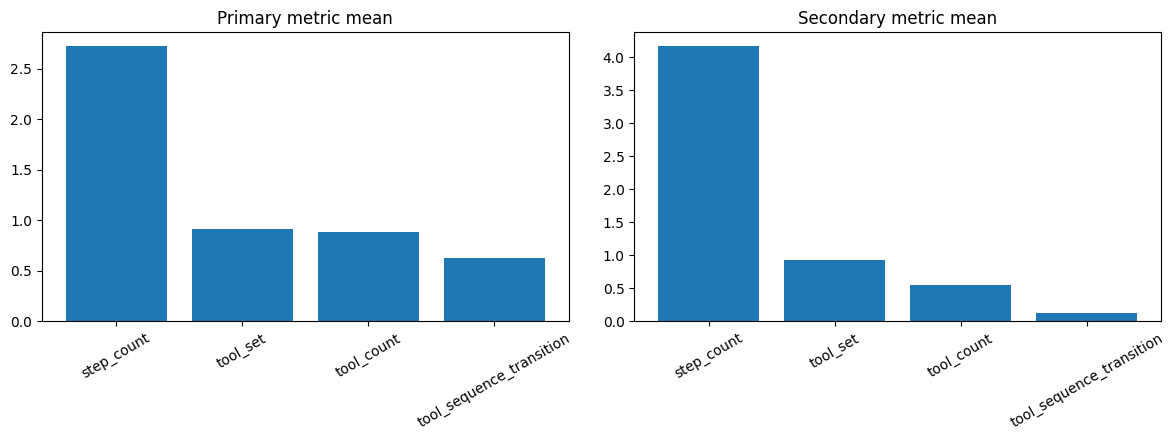

In [12]:
# ============================================================
# Optional: quick diagnostic bar plots of the final summary
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(df_exec_prediction_summary["task"], df_exec_prediction_summary["primary_mean"])
axes[0].set_title("Primary metric mean")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(df_exec_prediction_summary["task"], df_exec_prediction_summary["secondary_mean"])
axes[1].set_title("Secondary metric mean")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()